In [1]:
# ================================
# Weather Trend Analysis
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported! 🚀")

Libraries imported! 🚀


In [2]:
# Download historical weather data for Mumbai using Open-Meteo API
# Free API — no key needed!

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 19.0760,      # Mumbai latitude
    "longitude": 72.8777,     # Mumbai longitude
    "start_date": "2019-01-01",
    "end_date": "2023-12-31",
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "windspeed_10m_max",
        "relative_humidity_2m_max"
    ],
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
data = response.json()

# Convert to DataFrame
df = pd.DataFrame(data['daily'])
df['time'] = pd.to_datetime(df['time'])
df.rename(columns={
    'time': 'Date',
    'temperature_2m_max': 'Max_Temp',
    'temperature_2m_min': 'Min_Temp',
    'precipitation_sum': 'Rainfall',
    'windspeed_10m_max': 'Wind_Speed',
    'relative_humidity_2m_max': 'Humidity'
}, inplace=True)

# Add useful columns
df['Avg_Temp'] = (df['Max_Temp'] + df['Min_Temp']) / 2
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon',
    9: 'Monsoon', 10: 'Autumn', 11: 'Autumn'
})

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

        Date  Max_Temp  Min_Temp  Rainfall  Wind_Speed  Humidity  Avg_Temp  \
0 2019-01-01      29.8      14.9       0.0        13.9        81     22.35   
1 2019-01-02      30.0      15.4       0.0        17.9        77     22.70   
2 2019-01-03      29.4      15.0       0.0        13.0        78     22.20   
3 2019-01-04      30.0      15.4       0.0        16.3        88     22.70   
4 2019-01-05      28.4      15.9       0.0        15.6        86     22.15   

   Year  Month  Season  
0  2019      1  Winter  
1  2019      1  Winter  
2  2019      1  Winter  
3  2019      1  Winter  
4  2019      1  Winter  

Shape: (1826, 10)

Missing values:
Date          0
Max_Temp      0
Min_Temp      0
Rainfall      0
Wind_Speed    0
Humidity      0
Avg_Temp      0
Year          0
Month         0
Season        0
dtype: int64


In [3]:
print("Mumbai Weather Statistics (2019-2023)")
print("=" * 45)
print(f"Average Temperature: {df['Avg_Temp'].mean():.1f}°C")
print(f"Highest Temperature: {df['Max_Temp'].max():.1f}°C")
print(f"Lowest Temperature:  {df['Min_Temp'].min():.1f}°C")
print(f"Total Rainfall:      {df['Rainfall'].sum():.0f} mm")
print(f"Average Humidity:    {df['Humidity'].mean():.1f}%")
print(f"Max Wind Speed:      {df['Wind_Speed'].max():.1f} km/h")

print("\nAverage Temperature by Season:")
print(df.groupby('Season')['Avg_Temp'].mean().round(1))

print("\nAverage Rainfall by Season:")
print(df.groupby('Season')['Rainfall'].mean().round(1))


Mumbai Weather Statistics (2019-2023)
Average Temperature: 27.0°C
Highest Temperature: 38.6°C
Lowest Temperature:  13.0°C
Total Rainfall:      12359 mm
Average Humidity:    88.7%
Max Wind Speed:      61.9 km/h

Average Temperature by Season:
Season
Autumn     27.4
Monsoon    27.0
Summer     28.6
Winter     24.8
Name: Avg_Temp, dtype: float64

Average Rainfall by Season:
Season
Autumn      2.1
Monsoon    18.5
Summer      0.7
Winter      0.3
Name: Rainfall, dtype: float64


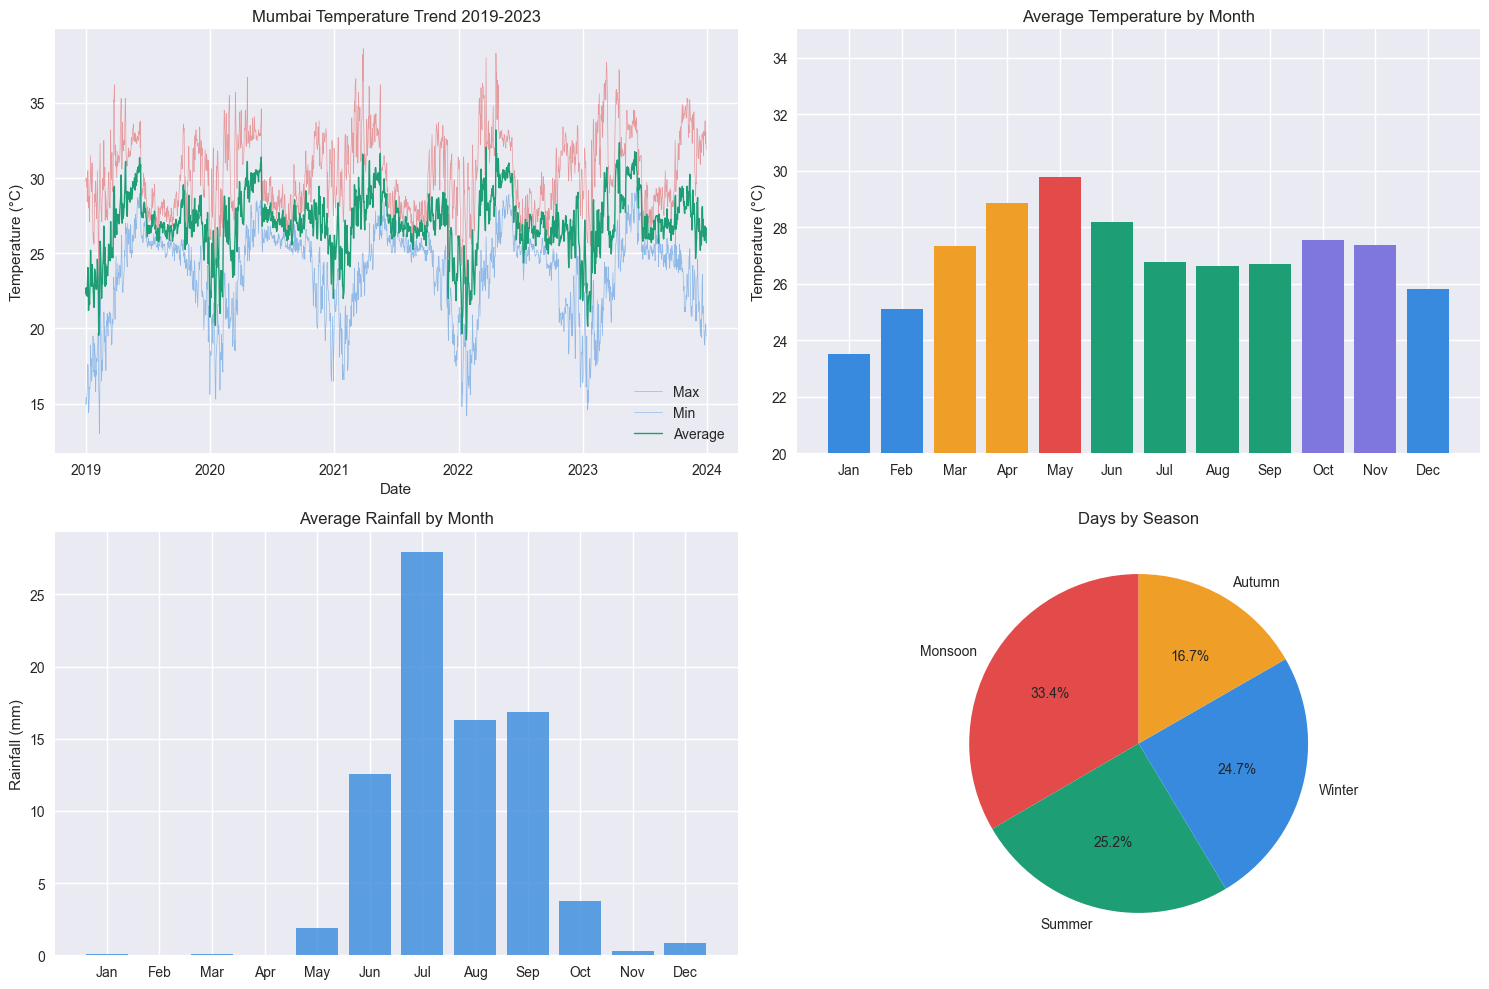

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Temperature over time
axes[0,0].plot(df['Date'], df['Max_Temp'], 
               color='#E24B4A', alpha=0.5, linewidth=0.5, label='Max')
axes[0,0].plot(df['Date'], df['Min_Temp'], 
               color='#378ADD', alpha=0.5, linewidth=0.5, label='Min')
axes[0,0].plot(df['Date'], df['Avg_Temp'], 
               color='#1D9E75', linewidth=1, label='Average')
axes[0,0].set_title('Mumbai Temperature Trend 2019-2023')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].legend()

# 2. Monthly average temperature
monthly_temp = df.groupby('Month')['Avg_Temp'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(months, monthly_temp, 
              color=['#378ADD','#378ADD','#EF9F27','#EF9F27',
                     '#E24B4A','#1D9E75','#1D9E75','#1D9E75',
                     '#1D9E75','#7F77DD','#7F77DD','#378ADD'])
axes[0,1].set_title('Average Temperature by Month')
axes[0,1].set_ylabel('Temperature (°C)')
axes[0,1].set_ylim(20, 35)

# 3. Monthly rainfall
monthly_rain = df.groupby('Month')['Rainfall'].mean()
axes[1,0].bar(months, monthly_rain, color='#378ADD', alpha=0.8)
axes[1,0].set_title('Average Rainfall by Month')
axes[1,0].set_ylabel('Rainfall (mm)')

# 4. Season distribution
season_counts = df['Season'].value_counts()
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#EF9F27']
axes[1,1].pie(season_counts, labels=season_counts.index, 
               colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Days by Season')

plt.tight_layout()
plt.show()

Yearly Weather Trends:
      Avg_Temp  Rainfall  Humidity  Wind_Speed
Year                                          
2019     26.60    2604.6     90.91       19.32
2020     27.00    2773.6     89.66       19.13
2021     27.05    2280.9     89.48       19.11
2022     26.76    2651.6     87.29       19.24
2023     27.39    2048.1     86.27       19.45


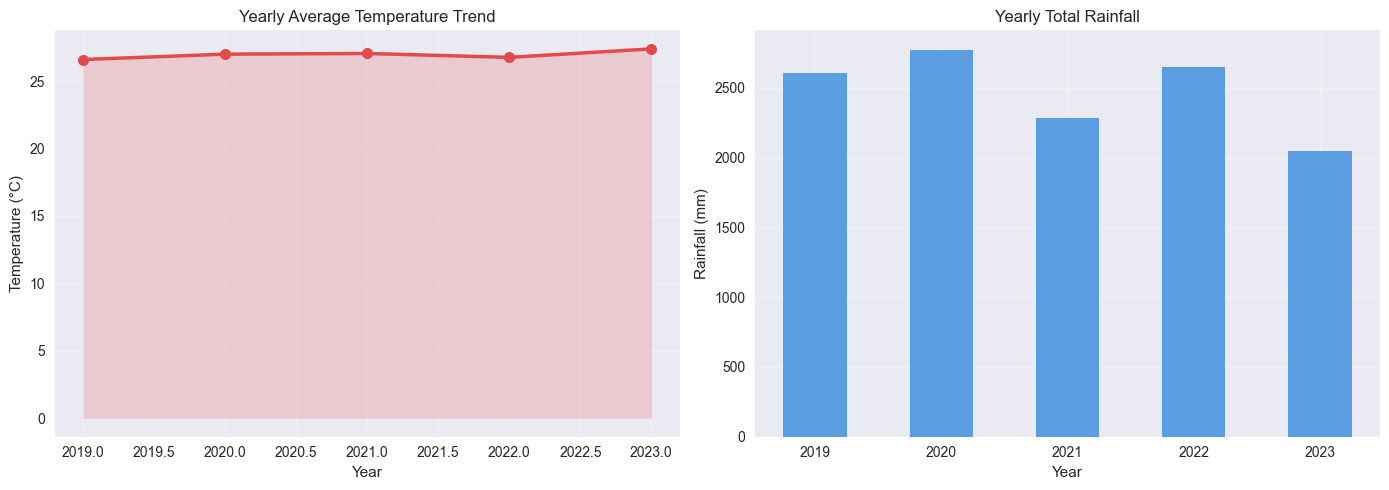

In [5]:
# Yearly trends
yearly = df.groupby('Year').agg({
    'Avg_Temp': 'mean',
    'Rainfall': 'sum',
    'Humidity': 'mean',
    'Wind_Speed': 'mean'
}).round(2)

print("Yearly Weather Trends:")
print(yearly)

# Plot yearly temperature trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature trend
axes[0].plot(yearly.index, yearly['Avg_Temp'], 
             marker='o', color='#E24B4A', linewidth=2.5,
             markersize=8, label='Avg Temperature')
axes[0].fill_between(yearly.index, yearly['Avg_Temp'], 
                      alpha=0.2, color='#E24B4A')
axes[0].set_title('Yearly Average Temperature Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.3)

# Rainfall trend
axes[1].bar(yearly.index, yearly['Rainfall'], 
            color='#378ADD', alpha=0.8, width=0.5)
axes[1].set_title('Yearly Total Rainfall')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

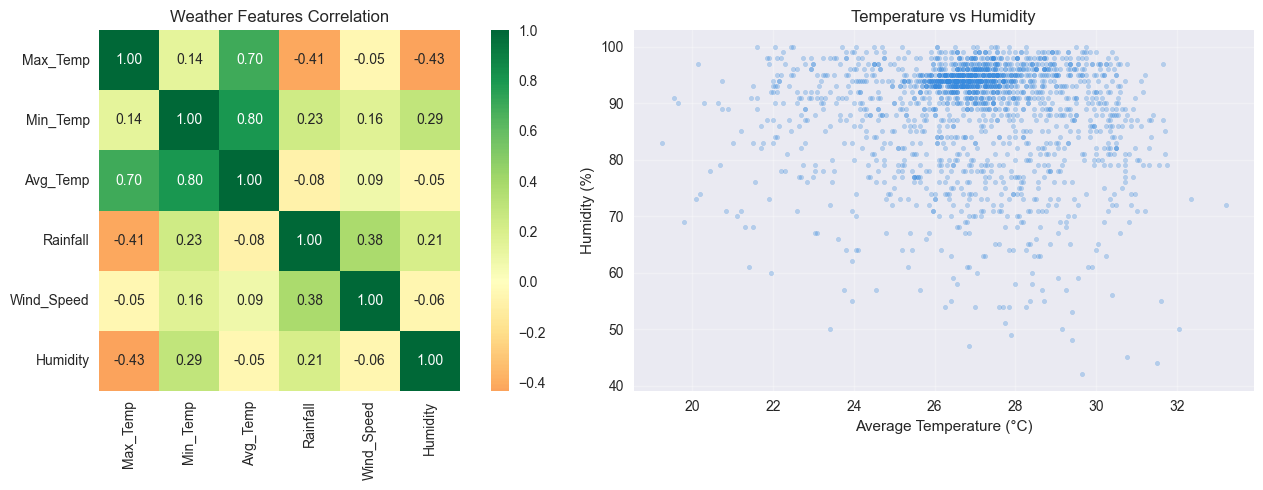


Key Correlations:
Temperature vs Humidity: -0.05
Temperature vs Rainfall: -0.08
Humidity vs Rainfall:    0.21


In [6]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
corr = df[['Max_Temp', 'Min_Temp', 'Avg_Temp', 
           'Rainfall', 'Wind_Speed', 'Humidity']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='RdYlGn', ax=axes[0],
            center=0, square=True)
axes[0].set_title('Weather Features Correlation')

# Temperature vs Humidity scatter
axes[1].scatter(df['Avg_Temp'], df['Humidity'], 
                alpha=0.3, color='#378ADD', s=10)
axes[1].set_xlabel('Average Temperature (°C)')
axes[1].set_ylabel('Humidity (%)')
axes[1].set_title('Temperature vs Humidity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print(f"Temperature vs Humidity: {corr['Avg_Temp']['Humidity']:.2f}")
print(f"Temperature vs Rainfall: {corr['Avg_Temp']['Rainfall']:.2f}")
print(f"Humidity vs Rainfall:    {corr['Humidity']['Rainfall']:.2f}")

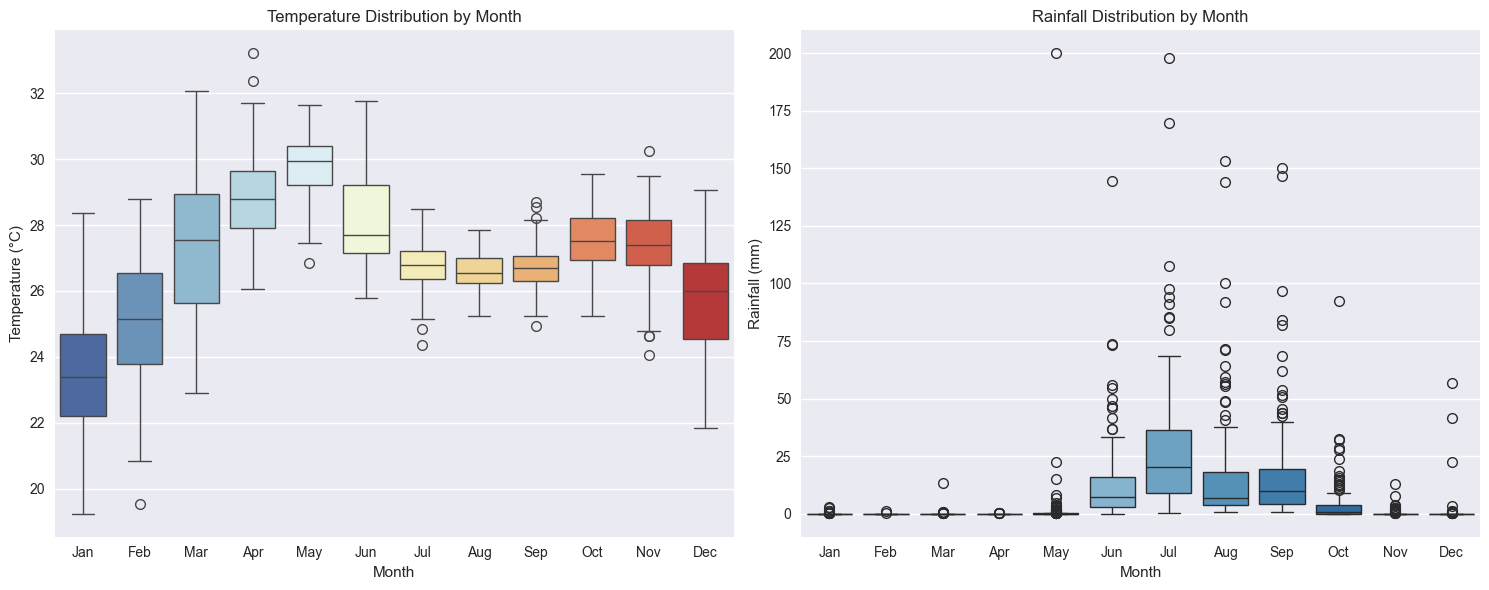

In [7]:
# Monthly temperature distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

# Temperature boxplot by month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Month_Name'] = pd.Categorical(df['Month_Name'], 
                                   categories=months, ordered=True)

sns.boxplot(data=df, x='Month_Name', y='Avg_Temp', 
            ax=axes[0], palette='RdYlBu_r')
axes[0].set_title('Temperature Distribution by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Temperature (°C)')

# Rainfall boxplot by month
sns.boxplot(data=df, x='Month_Name', y='Rainfall',
            ax=axes[1], palette='Blues')
axes[1].set_title('Rainfall Distribution by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Rainfall (mm)')

plt.tight_layout()
plt.show()

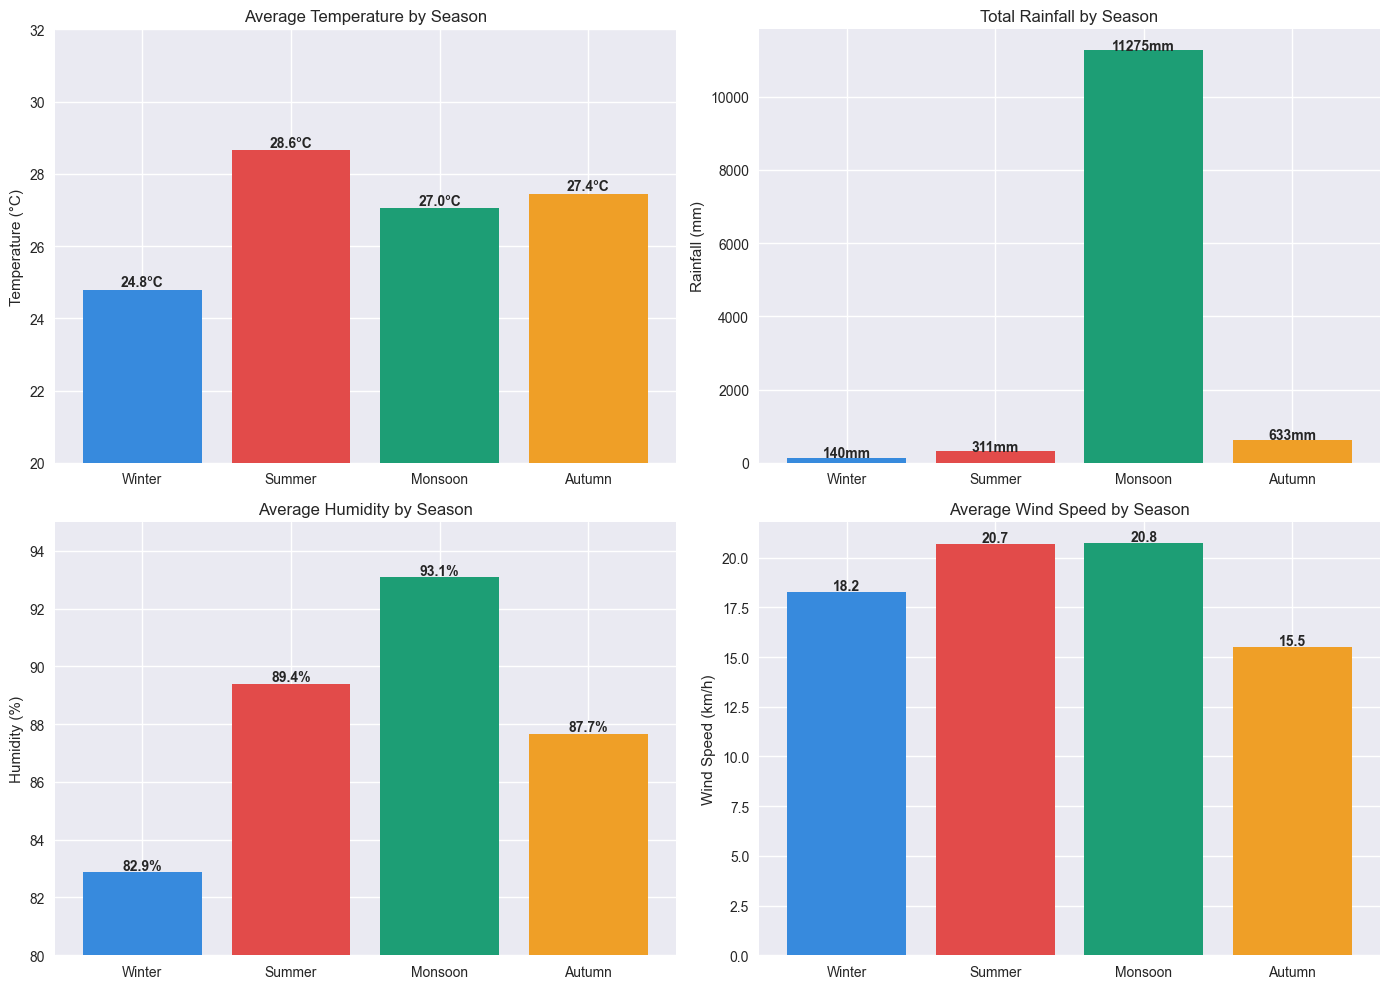

In [8]:
# Season wise analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seasons = ['Winter', 'Summer', 'Monsoon', 'Autumn']
colors = ['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27']

# Temperature by season
season_temp = df.groupby('Season')['Avg_Temp'].mean()
axes[0,0].bar(seasons, [season_temp[s] for s in seasons], 
              color=colors)
axes[0,0].set_title('Average Temperature by Season')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].set_ylim(20, 32)
for i, v in enumerate([season_temp[s] for s in seasons]):
    axes[0,0].text(i, v + 0.1, f'{v:.1f}°C', 
                   ha='center', fontweight='bold')

# Rainfall by season
season_rain = df.groupby('Season')['Rainfall'].sum()
axes[0,1].bar(seasons, [season_rain[s] for s in seasons],
              color=colors)
axes[0,1].set_title('Total Rainfall by Season')
axes[0,1].set_ylabel('Rainfall (mm)')
for i, v in enumerate([season_rain[s] for s in seasons]):
    axes[0,1].text(i, v + 10, f'{v:.0f}mm',
                   ha='center', fontweight='bold')

# Humidity by season
season_hum = df.groupby('Season')['Humidity'].mean()
axes[1,0].bar(seasons, [season_hum[s] for s in seasons],
              color=colors)
axes[1,0].set_title('Average Humidity by Season')
axes[1,0].set_ylabel('Humidity (%)')
axes[1,0].set_ylim(80, 95)
for i, v in enumerate([season_hum[s] for s in seasons]):
    axes[1,0].text(i, v + 0.1, f'{v:.1f}%',
                   ha='center', fontweight='bold')

# Wind speed by season
season_wind = df.groupby('Season')['Wind_Speed'].mean()
axes[1,1].bar(seasons, [season_wind[s] for s in seasons],
              color=colors)
axes[1,1].set_title('Average Wind Speed by Season')
axes[1,1].set_ylabel('Wind Speed (km/h)')
for i, v in enumerate([season_wind[s] for s in seasons]):
    axes[1,1].text(i, v + 0.1, f'{v:.1f}',
                   ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
import os
import pickle

# Create folder
os.makedirs('D:\\Shreyash_Projects\\Weather-Trend-Analysis', exist_ok=True)

# Save processed dataframe
df.to_csv('D:\\Shreyash_Projects\\Weather-Trend-Analysis\\mumbai_weather.csv', 
          index=False)

print("Data saved! ✅")
print(f"Shape: {df.shape}")

Data saved! ✅
Shape: (1826, 11)
